In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO HEAT PUMP → STOVE OPPORTUNITY CUSTOMERS
print("\n🎯 FILTERING TO HEAT PUMP → STOVE OPPORTUNITY")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Get customers with heat pump
has_heat_pump = df_quotes.groupby('numero_compte')['famille_equipement_produit'].apply(
    lambda x: 'Pompe à chaleur' in x.values
)

# Get customers with stove
has_stove = df_quotes.groupby('numero_compte')['famille_equipement_produit'].apply(
    lambda x: 'Poêle' in x.values
)

# Heat pump → Stove opportunity: has heat pump, no stove
hp_to_stove_ids = has_heat_pump[has_heat_pump & (~has_stove)].index.tolist()

# Filter data
df_quotes_hp_stove = df_quotes[df_quotes['numero_compte'].isin(hp_to_stove_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Heat pump → Stove opportunity: {len(hp_to_stove_ids):,} customers")
print(f"Quotes: {len(df_quotes_hp_stove):,}")

# Save to file
df_quotes_hp_stove.to_csv('cleaned_quote_data_hp_stove.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_hp_stove.csv")


🎯 FILTERING TO HEAT PUMP → STOVE OPPORTUNITY
Original customers: 25,716
Heat pump → Stove opportunity: 4,782 customers
Quotes: 7,586

✅ Saved to cleaned_quote_data_hp_stove.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_hp_stove.csv')


📊 Original quote data: 7,586 quotes from 4,782 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 4,782, Quotes: 7,199
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 4,782 customers | 41.4% converters
⏱️  Execution time: 2.0 seconds
✅ SUCCESS! Achieved ≤ 3s target
CREATING SEQUENCE FEATURES (mode: first_conversion)
  Total quotes: 7,586
  Total customers: 4,782
  Using product column: regroup_famille_equipement_produit_principal
  Window days: 30
  Filtering post-first-purchase data...
    Customers after filter: 4,782
    Quotes after filter: 7,203
⚡ Processing 4,782 customers with sequence features...

  Adding categorical features...

✅ SEQUENCE FEATURES CREATED
  Total customers: 4,782
  Converters: 1,980 (41.4%)
  Features created: 21
  Product column used: regroup_famille_equipement_produit_p

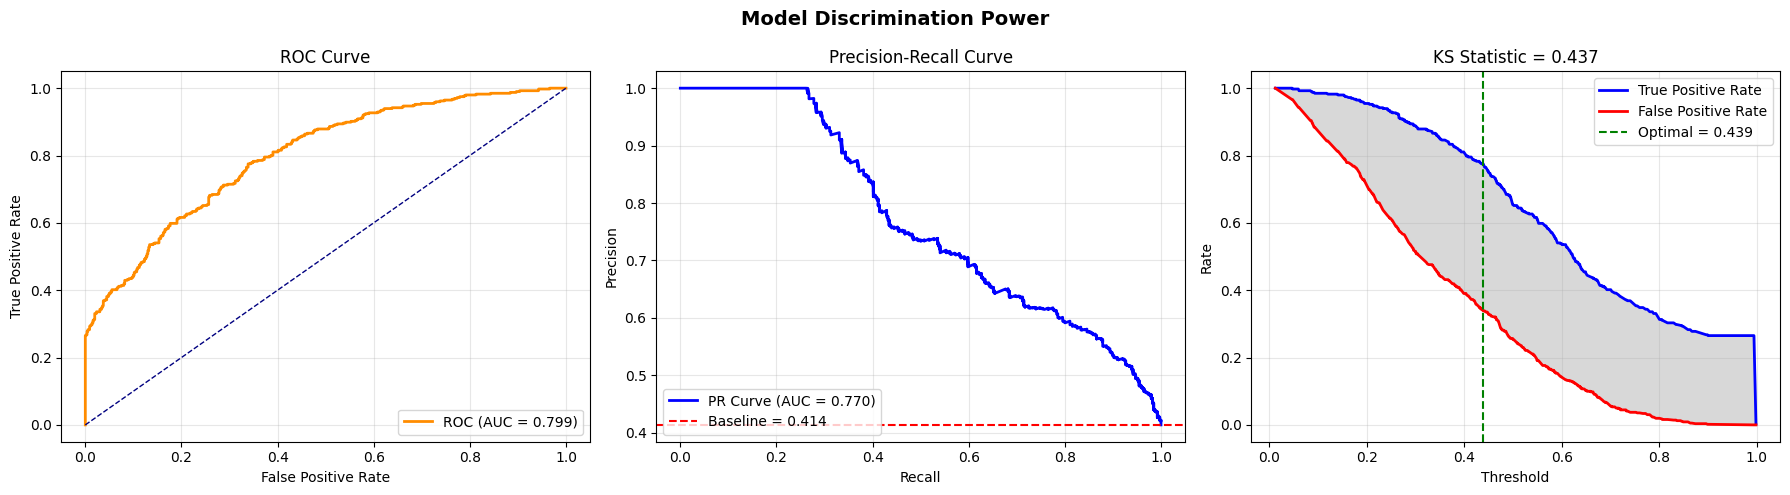

• ROC-AUC: 0.7987
• PR-AUC: 0.7695
• KS Statistic: 0.437 (GOOD discrimination)
• Optimal Threshold: 0.439

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.997
Decile 10 mean prob: 0.072


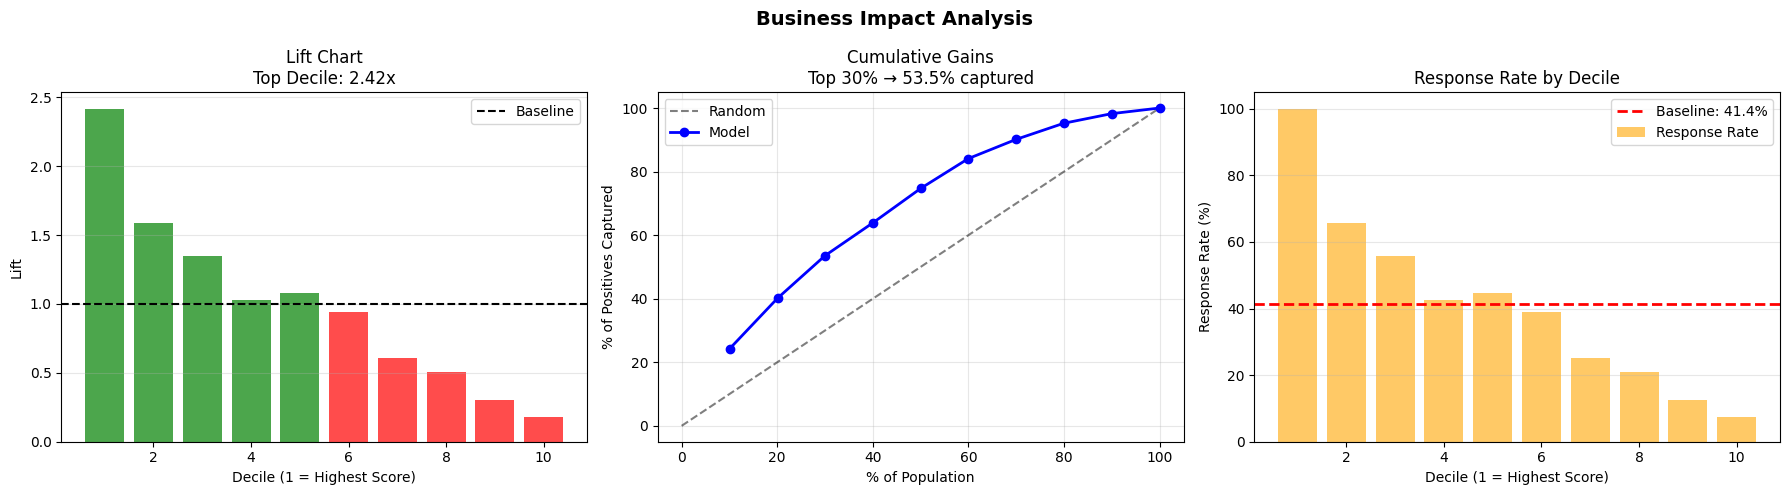

• Top Decile Lift: 0.18x
• Top 30% captures: 53.5% of positives
• Baseline response rate: 41.4%
• Top decile response: 100.0%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


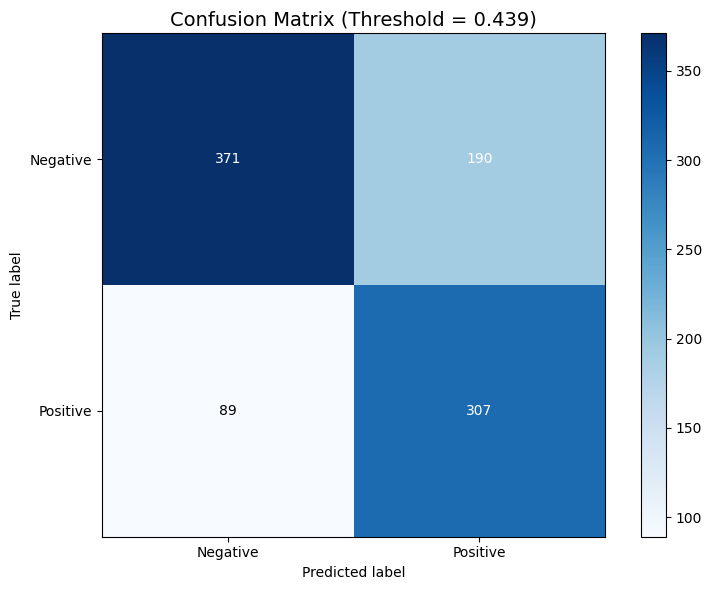

At threshold 0.439:
• Accuracy: 0.708
• Precision: 0.618
• Recall: 0.775
• F1-Score: 0.688
• True Positives: 307
• False Positives: 190
• True Negatives: 371
• False Negatives: 89

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.437 (GOOD discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.18x better than random
   Coverage: Top 30% → 53.5% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.7987 (Excellent if >0.8)
   PR-AUC: 0.7695 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.439
   Precision at threshold: 0.618
   Recall at threshold: 0.775

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                        feature  importance
178     quote_consistency_score    0.085679
251    max_price_over_min_price    0.060725
287    value_score_bin_quantile    0.049190
255      max_price_bin_quantile    0.036414
155          engagement_density    0.026610
250                 value_score    0.024273
242         price_x_consistency    0.011488
38 

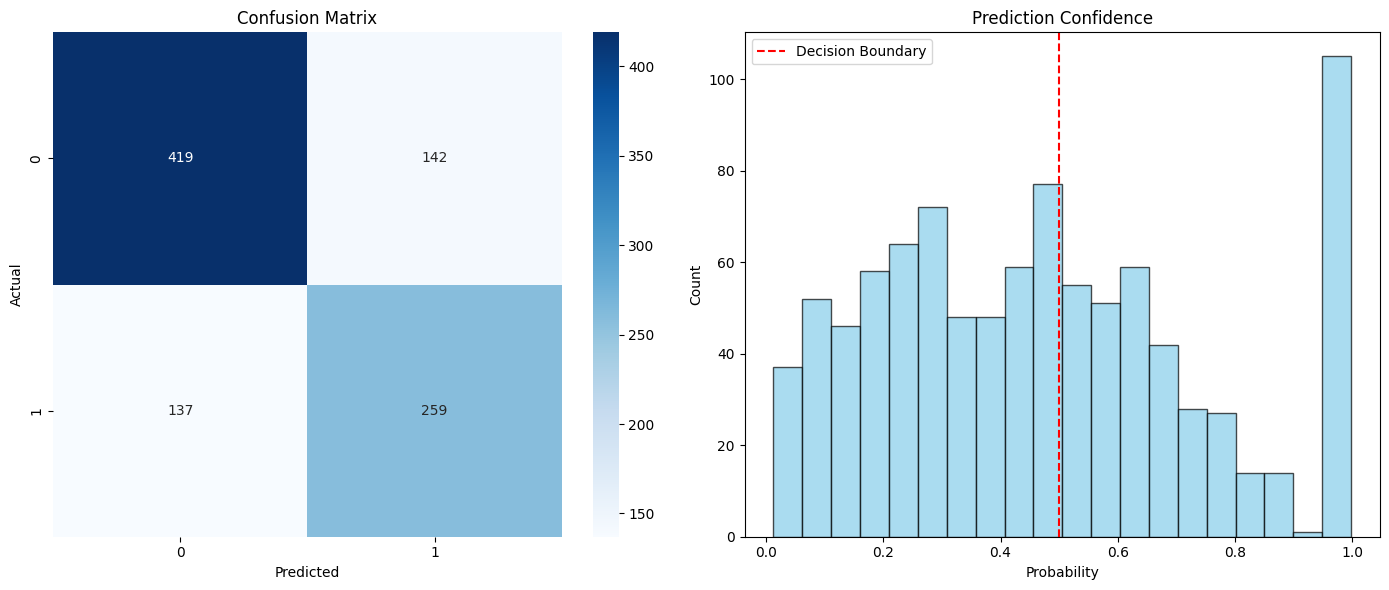

In [4]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])